# Analisis Temporal Rescale — Simulasi dan Visualisasi

Notebook ini menguji augmentasi **Temporal Rescale** dengan memanggil langsung kelas `TemporalRescale`.

**Cara kerja `TemporalRescale.__call__`:**
1. Sampling faktor skala temporal: $f \sim \mathcal{U}(L, U)$ di mana $L = 1 - p$, $U = 1 + p$, $p$ = `temp_scaling`
2. Hitung panjang baru: $T_{new} = \lfloor T \times f \rfloor$
3. Klip ke batas kalimat: $T_{new} = \text{clip}(T_{new},\, \text{min\_len},\, \text{max\_len})$
4. Bulatkan ke kelipatan 4: alignment untuk Conv1D
5. Resample frame:
   - Jika $T_{new} \leq T$: **subsample** tanpa penggantian (`random.sample`)
   - Jika $T_{new} > T$: **upsample** dengan penggantian (`random.choices`)

| Cell | Konten |
|------|--------|
| 4 | Simulasi perhitungan 5 epoch |
| 5 | Boxplot panjang sekuens per kalimat (P1–P5, R1–R4) |
| 6 | Visualisasi timeline baseline vs rescale 5 epoch |
| 7 | Distribusi faktor skala $f \sim \mathcal{U}(L, U)$ dalam 40 epoch |

## 1. Setup

In [1]:
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from collections import defaultdict

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

PICKLE_FILE  = '../data/pickle/pose_bisindo.pkl'
OUTPUT_DIR   = 'docs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SELECTED_ID  = 'P1_S15_R1'
TEMP_SCALING = 0.2
N_EPOCHS     = 5
ALLOWED_REPS = {'R1', 'R2', 'R3', 'R4'}

COLOR_BASELINE = '#2166AC'
COLOR_SUB      = '#D6604D'   # subsample (T_new <= T)
COLOR_UP       = '#4DAC26'   # upsample  (T_new >  T)
EPOCH_COLORS   = ['#D6604D', '#E07B39', '#8B5E9E', '#2E8B57', '#C0392B']

print(f'temp_scaling : {TEMP_SCALING}  →  L={1-TEMP_SCALING:.1f}, U={1+TEMP_SCALING:.1f}')
print(f'N_EPOCHS     : {N_EPOCHS}')

temp_scaling : 0.2  →  L=0.8, U=1.2
N_EPOCHS     : 5


## 2. Definisi `SENTENCE_LENGTH_BOUNDS` dan Kelas `TemporalRescale`

In [2]:
SENTENCE_LENGTH_BOUNDS = {
    "S01": {"min_len": 115, "max_len": 245},
    "S02": {"min_len": 179, "max_len": 255},
    "S03": {"min_len": 105, "max_len": 180},
    "S04": {"min_len": 184, "max_len": 315},
    "S05": {"min_len": 172, "max_len": 485},
    "S06": {"min_len": 110, "max_len": 235},
    "S07": {"min_len": 220, "max_len": 390},
    "S08": {"min_len": 159, "max_len": 380},
    "S09": {"min_len": 194, "max_len": 310},
    "S10": {"min_len":  95, "max_len": 185},
    "S11": {"min_len": 123, "max_len": 215},
    "S12": {"min_len": 200, "max_len": 335},
    "S13": {"min_len": 150, "max_len": 290},
    "S14": {"min_len": 135, "max_len": 330},
    "S15": {"min_len":  95, "max_len": 210},
    "S16": {"min_len": 154, "max_len": 320},
    "S17": {"min_len": 185, "max_len": 330},
    "S18": {"min_len": 127, "max_len": 240},
    "S19": {"min_len": 155, "max_len": 380},
    "S20": {"min_len":  96, "max_len": 220},
    "S21": {"min_len": 164, "max_len": 283},
    "S22": {"min_len": 179, "max_len": 375},
    "S23": {"min_len": 110, "max_len": 265},
    "S24": {"min_len":  81, "max_len": 165},
    "S25": {"min_len": 203, "max_len": 465},
    "S26": {"min_len": 183, "max_len": 310},
    "S27": {"min_len":  95, "max_len": 240},
    "S28": {"min_len":  91, "max_len": 210},
    "S29": {"min_len": 145, "max_len": 230},
    "S30": {"min_len": 141, "max_len": 260},
}


class TemporalRescale(object):
    """
    Temporally rescale video by resampling frames.

    NOTE: downsampling is NO LONGER applied here. Follow with
    ``Downsample(ratio=0.5)`` to reproduce the legacy behaviour.

    Args:
        temp_scaling (float): Temporal scaling factor. Video length is scaled
            between [1 - temp_scaling, 1 + temp_scaling].
        bounds (dict): Optional per-sentence {sentence_id: {min_len, max_len}}
            override. Defaults to SENTENCE_LENGTH_BOUNDS.
        default_min_len/default_max_len: Fallback bounds when sentence_id is
            unknown or not provided.
    """

    def __init__(self, temp_scaling=0.2, bounds=None,
                 default_min_len=32, default_max_len=230) -> None:
        self.bounds          = bounds if bounds is not None else SENTENCE_LENGTH_BOUNDS
        self.default_min_len = default_min_len
        self.default_max_len = default_max_len
        self.L = 1.0 - temp_scaling
        self.U = 1.0 + temp_scaling

    def __call__(self, clip, sentence_id=None, **kwargs):
        b       = self.bounds.get(sentence_id, {})
        min_len = b.get('min_len', self.default_min_len)
        max_len = b.get('max_len', self.default_max_len)

        vid_len = len(clip)
        new_len = int(vid_len * np.random.uniform(self.L, self.U))
        if new_len < min_len:
            new_len = min_len
        if new_len > max_len:
            new_len = max_len
        if (new_len - 4) % 4 != 0:
            new_len += 4 - (new_len - 4) % 4
        if new_len <= vid_len:
            index = sorted(random.sample(range(vid_len), new_len))
        else:
            index = sorted(random.choices(range(vid_len), k=new_len))
        return clip[index]


rescale = TemporalRescale(temp_scaling=TEMP_SCALING)
print(f'TemporalRescale: L={rescale.L}, U={rescale.U}')
print(f'  f ~ U({rescale.L}, {rescale.U})')
print(f'  T_new = int(T × f), kemudian diclip ke [min_len, max_len] dan dibulatkan ke kelipatan 4')

TemporalRescale: L=0.8, U=1.2
  f ~ U(0.8, 1.2)
  T_new = int(T × f), kemudian diclip ke [min_len, max_len] dan dibulatkan ke kelipatan 4


## 3. Load Data

In [3]:
with open(PICKLE_FILE, 'rb') as f:
    data = pickle.load(f)

# Filter P1–P5 dan R1–R4
video_ids = [
    v for v in data.keys()
    if not v.startswith('P6') and v.split('_')[2] in ALLOWED_REPS
]

assert SELECTED_ID in data, f'{SELECTED_ID} tidak ditemukan.'
skeleton    = data[SELECTED_ID]['keypoints'].copy()   # (T, 86, 2)
sentence_id = SELECTED_ID.split('_')[1]               # 'S15'
T           = len(skeleton)

seq_len = {vid: data[vid]['keypoints'].shape[0] for vid in video_ids}

print(f'Total videos (P1–P5, R1–R4) : {len(video_ids)}')
print(f'Video uji   : {SELECTED_ID}  |  sentence_id = {sentence_id}  |  T = {T}')
print(f'Bounds S15  : min={SENTENCE_LENGTH_BOUNDS[sentence_id]["min_len"]}  '
      f'max={SENTENCE_LENGTH_BOUNDS[sentence_id]["max_len"]}')
print(f'T_new range (sebelum clipping): [{int(T*rescale.L)}, {int(T*rescale.U)}]')

Total videos (P1–P5, R1–R4) : 600
Video uji   : P1_S15_R1  |  sentence_id = S15  |  T = 115
Bounds S15  : min=95  max=210
T_new range (sebelum clipping): [92, 138]


## 4. Simulasi Perhitungan — 5 Epoch

In [4]:
np.random.seed(7)
random.seed(7)

b       = SENTENCE_LENGTH_BOUNDS.get(sentence_id, {})
min_len = b.get('min_len', rescale.default_min_len)
max_len = b.get('max_len', rescale.default_max_len)

epoch_results = []

print('SIMULASI: Temporal Rescale pada 5 Epoch')
print('=' * 120)
print(f'Video: {SELECTED_ID}  |  T = {T}  |  sentence_id = {sentence_id}')
print(f'L = {rescale.L}, U = {rescale.U}  |  bounds = [{min_len}, {max_len}]')
print(f'Formula: T_new = int(T × f),  f ~ U({rescale.L}, {rescale.U})')
print('=' * 120)
header = (
    f"{'Ep':<5}"
    f"{'f ~ U(L,U)':<14}"
    f"{'T_new raw':<14}"
    f"{'Setelah clip':<16}"
    f"{'Setelah ×4':<14}"
    f"{'Mode':<14}"
    f"{'T output':<12}"
    f"Δ frame"
)
print(header)
print('-' * 120)

for ep in range(1, N_EPOCHS + 1):
    f         = np.random.uniform(rescale.L, rescale.U)
    new_len_raw = int(T * f)
    new_len_clip = np.clip(new_len_raw, min_len, max_len)
    # Bulatkan ke kelipatan 4
    new_len_4 = int(new_len_clip)
    if (new_len_4 - 4) % 4 != 0:
        new_len_4 += 4 - (new_len_4 - 4) % 4
    new_len_4 = np.clip(new_len_4, min_len, max_len)  # re-clip setelah rounding

    mode = 'subsample' if new_len_4 <= T else 'upsample'
    if new_len_4 <= T:
        index = sorted(random.sample(range(T), new_len_4))
    else:
        index = sorted(random.choices(range(T), k=new_len_4))
    result = skeleton[index]

    clipped = new_len_raw != new_len_clip
    clip_note = f'{int(new_len_clip)} (*)' if clipped else str(int(new_len_clip))

    epoch_results.append({
        'epoch'       : ep,
        'f'           : f,
        'new_len_raw' : new_len_raw,
        'new_len_clip': int(new_len_clip),
        'new_len_4'   : new_len_4,
        'mode'        : mode,
        'T_out'       : len(result),
        'result'      : result,
        'index'       : index,
        'clipped'     : clipped,
    })

    print(
        f"{ep:<5}"
        f"{f:.4f}{'':8}"
        f"int({T}×{f:.3f})={new_len_raw}{'':3}"
        f"{clip_note:<16}"
        f"{new_len_4:<14}"
        f"{mode:<14}"
        f"{len(result):<12}"
        f"{len(result)-T:+d}"
    )

print('=' * 120)
print('(*) T_new diclip ke batas kalimat [min_len, max_len]')
print()
print('→ f berbeda tiap epoch → T_new berbeda')
print('→ f < 1.0 → subsample (frame dipilih acak tanpa penggantian)')
print('→ f > 1.0 → upsample  (frame dipilih acak dengan penggantian)')
print('→ T_new selalu kelipatan 4 (alignment Conv1D)')

SIMULASI: Temporal Rescale pada 5 Epoch
Video: P1_S15_R1  |  T = 115  |  sentence_id = S15
L = 0.8, U = 1.2  |  bounds = [95, 210]
Formula: T_new = int(T × f),  f ~ U(0.8, 1.2)
Ep   f ~ U(L,U)    T_new raw     Setelah clip    Setelah ×4    Mode          T output    Δ frame
------------------------------------------------------------------------------------------------------------------------
1    0.8305        int(115×0.831)=95   95              96            subsample     96          -19
2    1.1120        int(115×1.112)=127   127             128           upsample      128         +13
3    0.9754        int(115×0.975)=112   112             112           subsample     112         -3
4    1.0894        int(115×1.089)=125   125             128           upsample      128         +13
5    1.1912        int(115×1.191)=136   136             136           upsample      136         +21
(*) T_new diclip ke batas kalimat [min_len, max_len]

→ f berbeda tiap epoch → T_new berbeda
→ f < 1.0 → su

## 5. Boxplot Panjang Sekuens per Kalimat

Data: P1–P5, R1–R4 (N=20 per kalimat). Menampilkan variasi panjang natural antar signer dan repetisi, yang menjadi dasar penetapan `SENTENCE_LENGTH_BOUNDS`.

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_3176\451771120.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


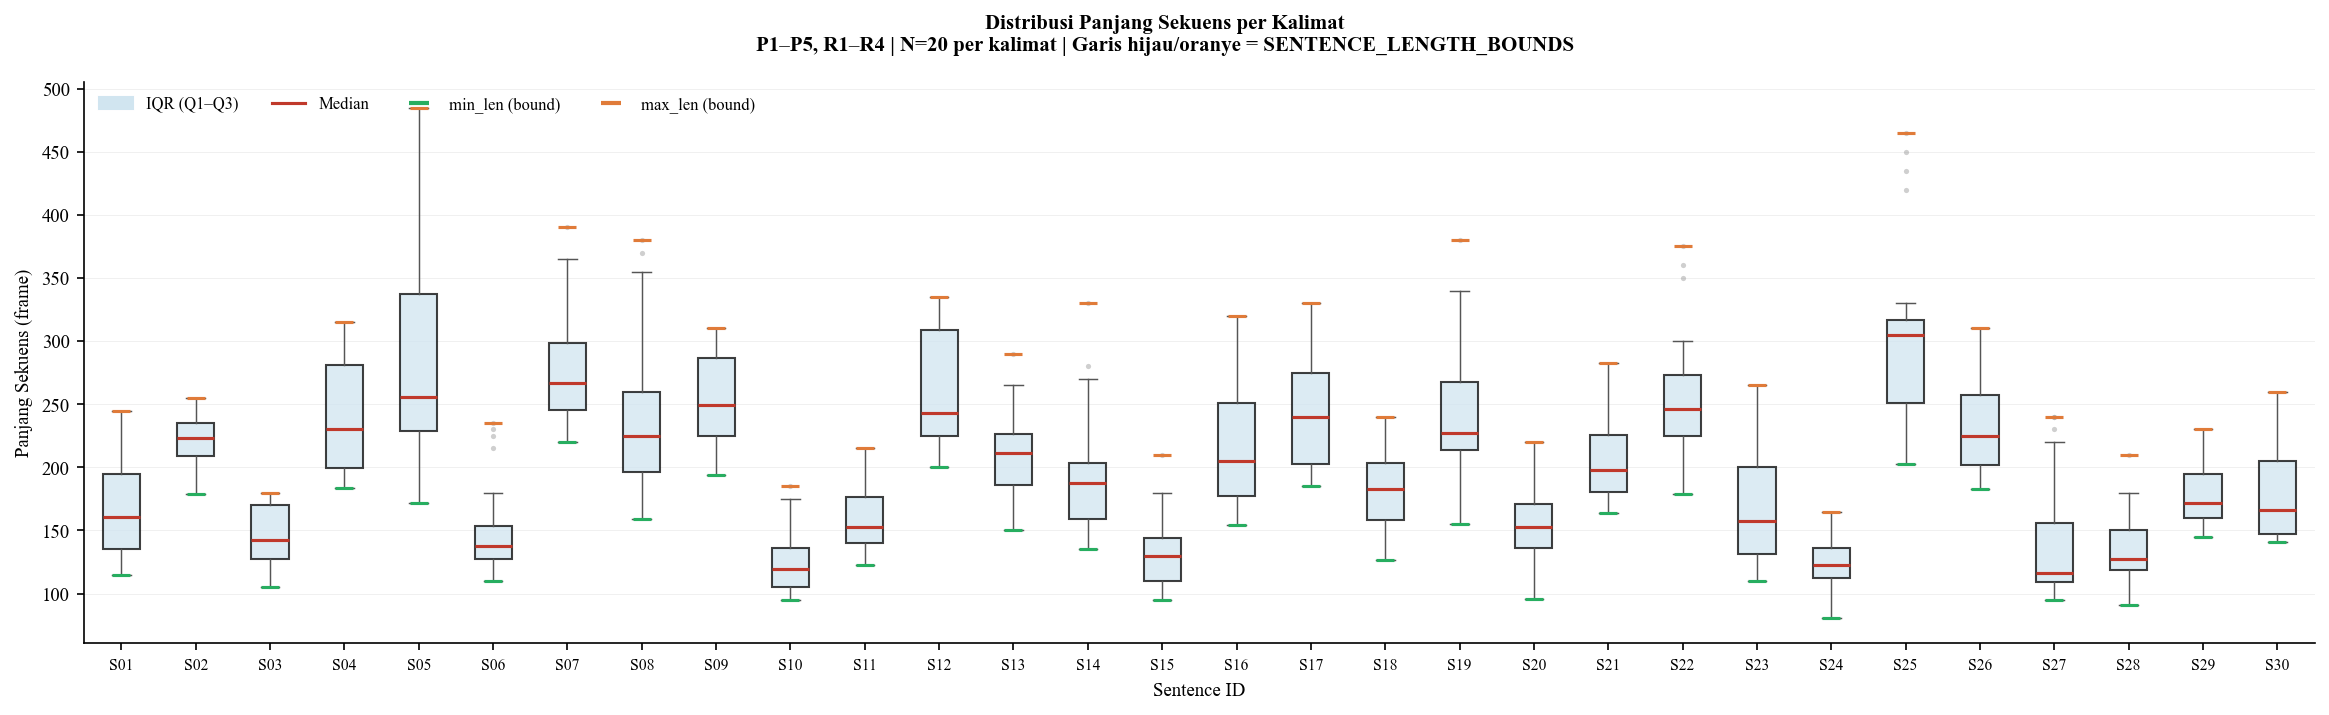

[SAVED] docs\temporal_rescale_boxplot_per_sentence.png

STATISTIK DESKRIPTIF PANJANG SEKUENS PER KALIMAT
Sentence      N    Min      Q1   Median     Mean      Q3    Max     Std     IQR   min_len   max_len
--------------------------------------------------------------------------------------------------------------
S01          20    115   135.2    161.0    167.8   195.0    245    39.2    59.8       115       245
S02          20    179   208.8    223.5    221.8   235.0    255    18.3    26.2       179       255
S03          20    105   127.5    142.5    145.8   170.0    180    22.7    42.5       105       180
S04          20    184   199.5    230.0    241.2   281.2    315    44.1    81.8       184       315
S05          20    172   229.0    256.0    290.1   337.5    485    90.0   108.5       172       485
S06          20    110   127.2    138.0    150.8   153.8    235    40.8    26.5       110       235
S07          20    220   245.5    266.5    280.1   298.8    390    46.7    53.2     

In [5]:
sent_lengths = defaultdict(list)
for vid, T_vid in seq_len.items():
    sent = vid.split('_')[1]
    sent_lengths[sent].append(T_vid)

sent_sorted = sorted(sent_lengths.keys())   # S01–S30 urut
bdata_sent  = [sent_lengths[s] for s in sent_sorted]
n_sent      = len(sent_sorted)

C_MED = '#C0392B'
fig_w = max(12, n_sent * 0.52)
fig, ax = plt.subplots(figsize=(fig_w, 4.8), dpi=150)

bp = ax.boxplot(
    bdata_sent,
    tick_labels=sent_sorted,
    patch_artist=True,
    medianprops=dict(color=C_MED, linewidth=1.5),
    whiskerprops=dict(linewidth=0.7, color='#555555'),
    capprops=dict(linewidth=0.7, color='#555555'),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.4,
                    markeredgecolor='none', markerfacecolor='#888888')
)
for patch in bp['boxes']:
    patch.set_facecolor('#D1E5F0')
    patch.set_alpha(0.75)

# Overlay min/max bounds sebagai scatter
for i, sent in enumerate(sent_sorted, 1):
    if sent in SENTENCE_LENGTH_BOUNDS:
        mn = SENTENCE_LENGTH_BOUNDS[sent]['min_len']
        mx = SENTENCE_LENGTH_BOUNDS[sent]['max_len']
        ax.scatter(i, mn, marker='_', s=80, color='#27AE60',
                   linewidths=1.5, zorder=4)
        ax.scatter(i, mx, marker='_', s=80, color='#E07B39',
                   linewidths=1.5, zorder=4)

ax.set_xlabel('Sentence ID', fontsize=9)
ax.set_ylabel('Panjang Sekuens (frame)', fontsize=9)
ax.tick_params(axis='x', labelsize=7.5, rotation=0)
ax.grid(axis='y', alpha=0.22, linewidth=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(
    handles=[
        mpatches.Patch(color='#D1E5F0', label='IQR (Q1–Q3)'),
        plt.Line2D([0],[0], color=C_MED, lw=1.5, label='Median'),
        plt.Line2D([0],[0], marker='_', color='#27AE60', lw=0,
                   markersize=10, markeredgewidth=2, label='min_len (bound)'),
        plt.Line2D([0],[0], marker='_', color='#E07B39', lw=0,
                   markersize=10, markeredgewidth=2, label='max_len (bound)'),
    ],
    fontsize=8, frameon=False, ncol=4, loc='upper left'
)

plt.suptitle(
    'Distribusi Panjang Sekuens per Kalimat\n'
    'P1–P5, R1–R4 | N=20 per kalimat | Garis hijau/oranye = SENTENCE_LENGTH_BOUNDS',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'temporal_rescale_boxplot_per_sentence.png')
plt.savefig(save_path, dpi=600)
plt.show()
print(f'[SAVED] {save_path}')

# ── Tabel deskriptif ──────────────────────────────────────────────────────────
print()
print('=' * 110)
print('STATISTIK DESKRIPTIF PANJANG SEKUENS PER KALIMAT')
print('=' * 110)
header = (
    f"{'Sentence':<10}"
    f"{'N':>5}"
    f"{'Min':>7}"
    f"{'Q1':>8}"
    f"{'Median':>9}"
    f"{'Mean':>9}"
    f"{'Q3':>8}"
    f"{'Max':>7}"
    f"{'Std':>8}"
    f"{'IQR':>8}"
    f"{'min_len':>10}"
    f"{'max_len':>10}"
)
print(header)
print('-' * 110)
for sent in sent_sorted:
    arr = np.array(sent_lengths[sent])
    q1, med, q3 = np.percentile(arr, [25, 50, 75])
    bd = SENTENCE_LENGTH_BOUNDS.get(sent, {})
    print(
        f"{sent:<10}"
        f"{len(arr):>5}"
        f"{arr.min():>7.0f}"
        f"{q1:>8.1f}"
        f"{med:>9.1f}"
        f"{arr.mean():>9.1f}"
        f"{q3:>8.1f}"
        f"{arr.max():>7.0f}"
        f"{arr.std():>8.1f}"
        f"{q3-q1:>8.1f}"
        f"{bd.get('min_len','—'):>10}"
        f"{bd.get('max_len','—'):>10}"
    )
print('=' * 110)

## 6. Visualisasi — Baseline vs Temporal Rescale pada 5 Epoch

Timeline bar horizontal. Warna menunjukkan mode resampling:
- **Biru** = frame baseline
- **Merah** = subsample ($T_{new} \leq T$, frame dibuang)
- **Hijau** = upsample ($T_{new} > T$, frame ditambah)

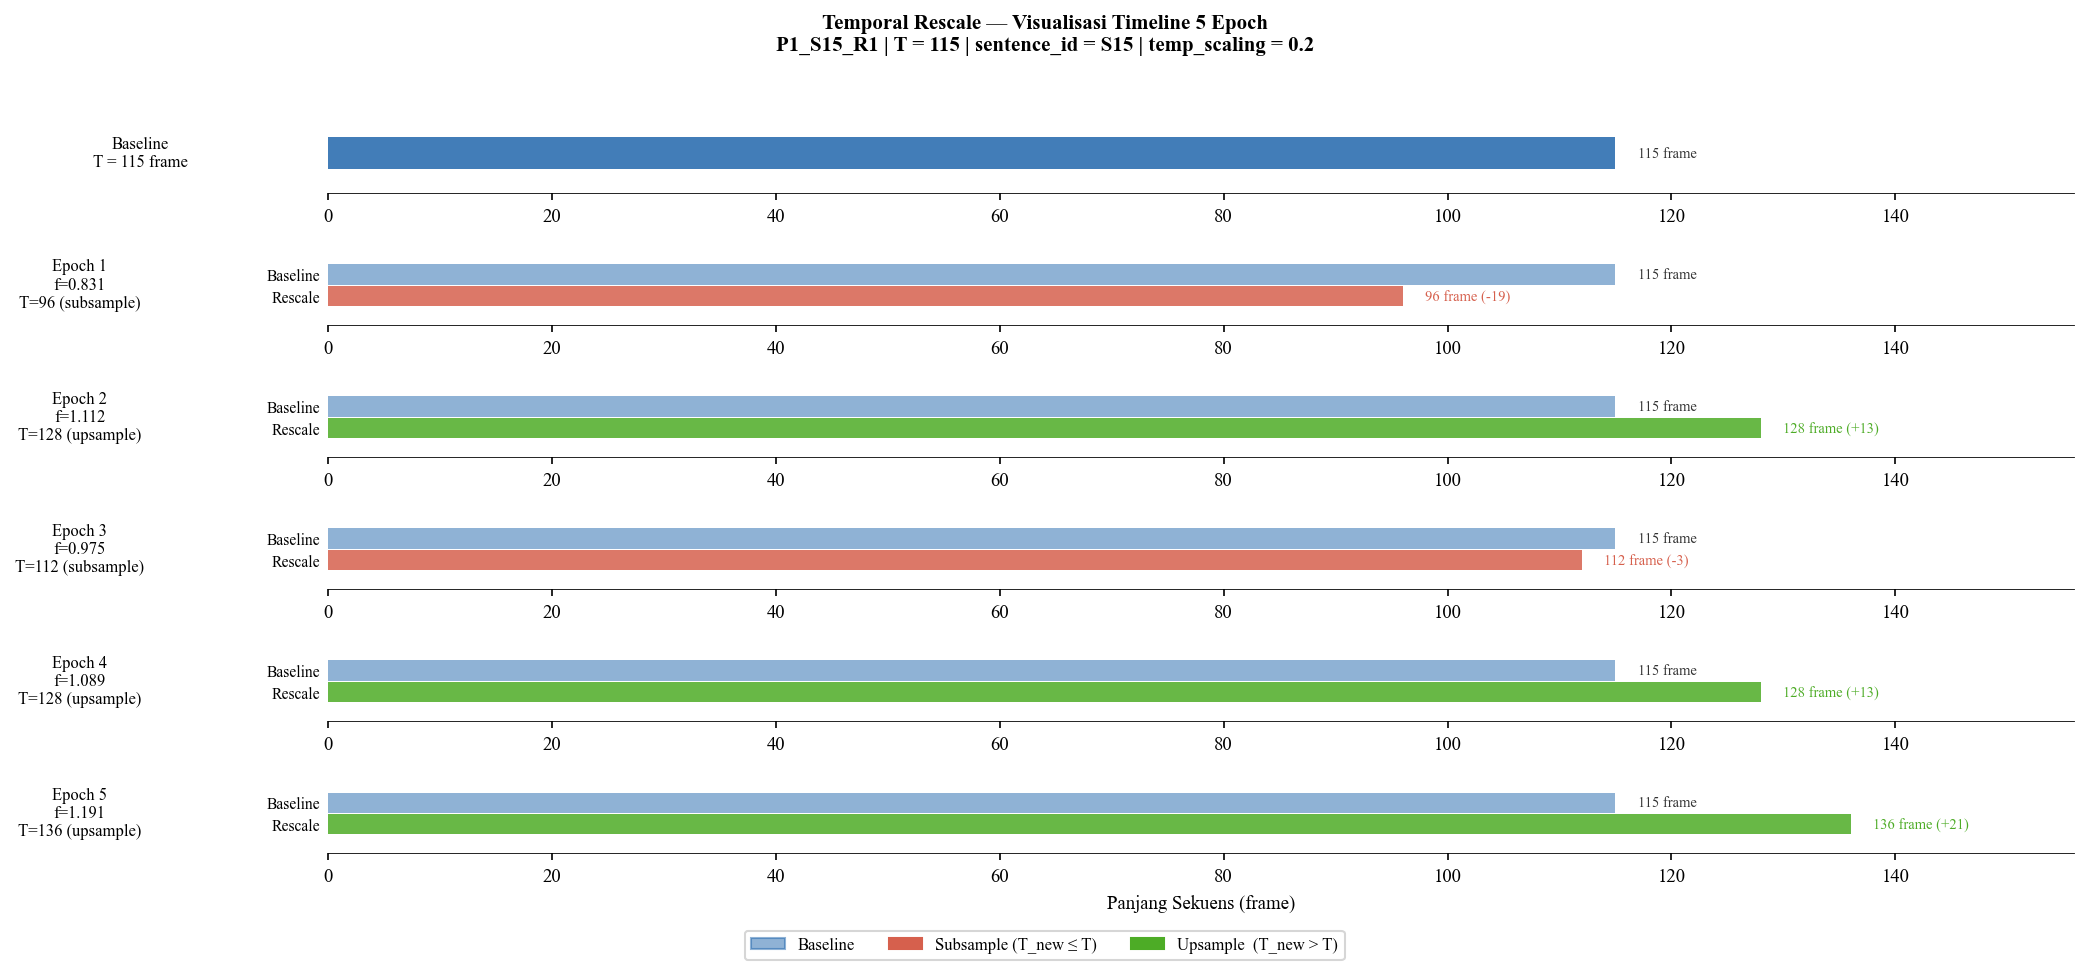

[SAVED] docs\temporal_rescale_timeline.png


In [6]:
fig, axes = plt.subplots(N_EPOCHS + 1, 1, figsize=(14, 6), sharex=False)

def draw_rescale_timeline(ax, T_orig, T_new, mode, ep_color, label):
    """
    Bar baseline (biru) + bar T_new (warna epoch).
    Keduanya digambar di sumbu yang sama supaya perbedaan panjang terlihat.
    """
    # Baseline
    ax.barh(0.15, T_orig, left=0, height=0.28,
            color=COLOR_BASELINE, alpha=0.5, label='Baseline')
    # Hasil rescale
    c = COLOR_SUB if mode == 'subsample' else COLOR_UP
    ax.barh(-0.15, T_new, left=0, height=0.28,
            color=c, alpha=0.85, label=f'Rescale ({mode})')

    ax.set_ylim(-0.55, 0.55)
    ax.set_yticks([0.15, -0.15])
    ax.set_yticklabels(['Baseline', 'Rescale'], fontsize=7.5)
    ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=90, va='center')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.4)
    ax.tick_params(axis='y', length=0)

    # Anotasi panjang
    ax.text(T_orig + 2, 0.15, f'{T_orig} frame', fontsize=7, va='center', color='#333')
    ax.text(T_new  + 2, -0.15,
            f'{T_new} frame ({T_new - T_orig:+d})',
            fontsize=7, va='center',
            color=COLOR_SUB if mode == 'subsample' else COLOR_UP)

# Baris 0 — Baseline saja
ax0 = axes[0]
ax0.barh(0, T, left=0, height=0.4, color=COLOR_BASELINE, alpha=0.85)
ax0.set_ylim(-0.5, 0.5)
ax0.set_yticks([])
ax0.set_ylabel(f'Baseline\nT = {T} frame', fontsize=8,
               rotation=0, labelpad=90, va='center')
ax0.text(T + 2, 0, f'{T} frame', fontsize=7, va='center', color='#333')
for spine in ['top', 'right', 'left']:
    ax0.spines[spine].set_visible(False)
ax0.spines['bottom'].set_linewidth(0.4)

# Baris 1–5 — Epoch
x_max = max(T, max(r['T_out'] for r in epoch_results)) + 20
for res in epoch_results:
    ep    = res['epoch']
    T_out = res['T_out']
    mode  = res['mode']
    f_val = res['f']
    label = (
        f'Epoch {ep}\n'
        f'f={f_val:.3f}\n'
        f'T={T_out} ({mode})'
    )
    draw_rescale_timeline(axes[ep], T, T_out, mode, EPOCH_COLORS[ep-1], label)
    axes[ep].set_xlim(0, x_max)

ax0.set_xlim(0, x_max)
axes[-1].set_xlabel('Panjang Sekuens (frame)', fontsize=9)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_BASELINE, alpha=0.5, label='Baseline'),
        mpatches.Patch(color=COLOR_SUB,      label='Subsample (T_new ≤ T)'),
        mpatches.Patch(color=COLOR_UP,       label='Upsample  (T_new > T)'),
    ],
    loc='lower center', ncol=3, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.04)
)
fig.suptitle(
    f'Temporal Rescale — Visualisasi Timeline 5 Epoch\n'
    f'{SELECTED_ID} | T = {T} | sentence_id = {sentence_id} | '
    f'temp_scaling = {TEMP_SCALING}',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'temporal_rescale_timeline.png')
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path}')

## 7. Distribusi Faktor Skala $f \sim \mathcal{U}(L, U)$ dalam 40 Epoch

Menampilkan nilai $f$ yang disampling per epoch, efek clipping ke `[min_len, max_len]`, dan distribusi $T_{new}$ aktual.

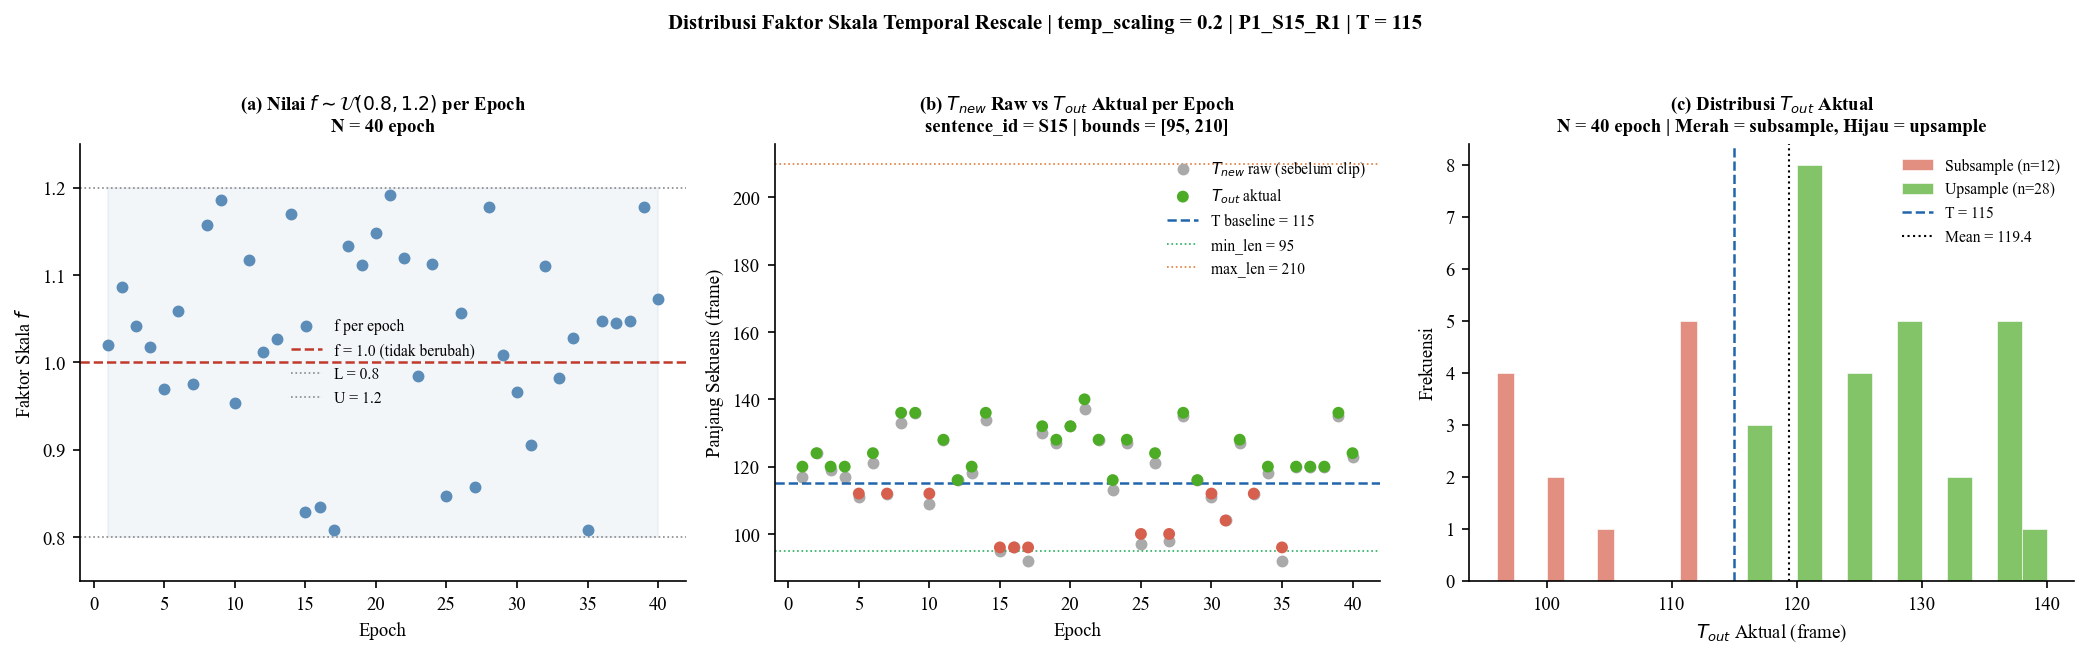

[SAVED] docs\temporal_rescale_distribusi.png


In [7]:
N_VIZ = 40
np.random.seed(0)
random.seed(0)

b_s15   = SENTENCE_LENGTH_BOUNDS[sentence_id]
mn, mx  = b_s15['min_len'], b_s15['max_len']

sim_f        = []
sim_T_raw    = []
sim_T_out    = []
sim_clipped  = []

for _ in range(N_VIZ):
    f         = np.random.uniform(rescale.L, rescale.U)
    T_raw_    = int(T * f)
    T_clip    = int(np.clip(T_raw_, mn, mx))
    T_4       = T_clip + (4 - (T_clip - 4) % 4) % 4
    T_4       = int(np.clip(T_4, mn, mx))
    sim_f.append(f)
    sim_T_raw.append(T_raw_)
    sim_T_out.append(T_4)
    sim_clipped.append(T_raw_ != T_clip)

sim_f       = np.array(sim_f)
sim_T_raw   = np.array(sim_T_raw)
sim_T_out   = np.array(sim_T_out)
sim_clipped = np.array(sim_clipped)
epochs_arr  = np.arange(1, N_VIZ + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# ── (a) Scatter f per epoch ───────────────────────────────────
ax = axes[0]
ax.scatter(epochs_arr, sim_f, s=22, c='#5B8DB8', zorder=3, label='f per epoch')
ax.axhline(1.0,        color='#C0392B', lw=1.2, ls='--', label='f = 1.0 (tidak berubah)')
ax.axhline(rescale.L,  color='#888',   lw=0.8, ls=':',  label=f'L = {rescale.L}')
ax.axhline(rescale.U,  color='#888',   lw=0.8, ls=':',  label=f'U = {rescale.U}')
ax.fill_between(epochs_arr, rescale.L, rescale.U, alpha=0.07, color='#5B8DB8')
ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel('Faktor Skala $f$', fontsize=9)
ax.set_ylim(rescale.L - 0.05, rescale.U + 0.05)
ax.set_title(
    f'(a) Nilai $f \\sim \\mathcal{{U}}({rescale.L}, {rescale.U})$ per Epoch\n'
    f'N = {N_VIZ} epoch',
    fontsize=9
)
ax.legend(fontsize=7.5, frameon=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ── (b) T_new raw vs T_out aktual per epoch ───────────────────
ax2 = axes[1]
ax2.scatter(epochs_arr, sim_T_raw, s=22, c='#AAAAAA',
            zorder=2, label='$T_{new}$ raw (sebelum clip)')
colors_out = [COLOR_SUB if t <= T else COLOR_UP for t in sim_T_out]
ax2.scatter(epochs_arr, sim_T_out, s=22, c=colors_out,
            zorder=3, label='$T_{out}$ aktual')
ax2.axhline(T,  color=COLOR_BASELINE, lw=1.2, ls='--', label=f'T baseline = {T}')
ax2.axhline(mn, color='#27AE60',      lw=0.8, ls=':',  label=f'min_len = {mn}')
ax2.axhline(mx, color='#E07B39',      lw=0.8, ls=':',  label=f'max_len = {mx}')
ax2.set_xlabel('Epoch', fontsize=9)
ax2.set_ylabel('Panjang Sekuens (frame)', fontsize=9)
ax2.set_title(
    f'(b) $T_{{new}}$ Raw vs $T_{{out}}$ Aktual per Epoch\n'
    f'sentence_id = {sentence_id} | bounds = [{mn}, {mx}]',
    fontsize=9
)
ax2.legend(fontsize=7.5, frameon=False)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# ── (c) Histogram T_out aktual ────────────────────────────────
ax3 = axes[2]
sub_vals = sim_T_out[sim_T_out <= T]
up_vals  = sim_T_out[sim_T_out > T]
if len(sub_vals):
    ax3.hist(sub_vals, bins=12, color=COLOR_SUB, alpha=0.7,
             edgecolor='white', lw=0.4, label=f'Subsample (n={len(sub_vals)})')
if len(up_vals):
    ax3.hist(up_vals,  bins=12, color=COLOR_UP,  alpha=0.7,
             edgecolor='white', lw=0.4, label=f'Upsample (n={len(up_vals)})')
ax3.axvline(T,  color=COLOR_BASELINE, lw=1.2, ls='--', label=f'T = {T}')
ax3.axvline(sim_T_out.mean(), color='black', lw=1.0, ls=':',
            label=f'Mean = {sim_T_out.mean():.1f}')
ax3.set_xlabel('$T_{out}$ Aktual (frame)', fontsize=9)
ax3.set_ylabel('Frekuensi', fontsize=9)
ax3.set_title(
    f'(c) Distribusi $T_{{out}}$ Aktual\n'
    f'N = {N_VIZ} epoch | Merah = subsample, Hijau = upsample',
    fontsize=9
)
ax3.legend(fontsize=7.5, frameon=False)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)

fig.suptitle(
    f'Distribusi Faktor Skala Temporal Rescale | temp_scaling = {TEMP_SCALING} | '
    f'{SELECTED_ID} | T = {T}',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'temporal_rescale_distribusi.png')
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path}')